# Pipeline Project

You will be using the provided data to create a machine learning model pipeline.

You must handle the data appropriately in your pipeline to predict whether an
item is recommended by a customer based on their review.
Note the data includes numerical, categorical, and text data.

You should ensure you properly train and evaluate your model.

Project data:

- Programmer: Diego Pintos
- Date: 25-March-2026

## The Data

The dataset has been anonymized and cleaned of missing values.

There are 8 features for to use to predict whether a customer recommends or does
not recommend a product.
The `Recommended IND` column gives whether a customer recommends the product
where `1` is recommended and a `0` is not recommended.
This is your model's target/

The features can be summarized as the following:

- **Clothing ID**: Integer Categorical variable that refers to the specific piece being reviewed.
- **Age**: Positive Integer variable of the reviewers age.
- **Title**: String variable for the title of the review.
- **Review Text**: String variable for the review body.
- **Positive Feedback Count**: Positive Integer documenting the number of other customers who found this review positive.
- **Division Name**: Categorical name of the product high level division.
- **Department Name**: Categorical name of the product department name.
- **Class Name**: Categorical name of the product class name.

The target:
- **Recommended IND**: Binary variable stating where the customer recommends the product where 1 is recommended, 0 is not recommended.

## Load Data

In [1]:
import pandas as pd

# Load data
df = pd.read_csv(
    'data/reviews.csv',
)

df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 18442 entries, 0 to 18441
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Clothing ID              18442 non-null  int64
 1   Age                      18442 non-null  int64
 2   Title                    18442 non-null  str  
 3   Review Text              18442 non-null  str  
 4   Positive Feedback Count  18442 non-null  int64
 5   Division Name            18442 non-null  str  
 6   Department Name          18442 non-null  str  
 7   Class Name               18442 non-null  str  
 8   Recommended IND          18442 non-null  int64
dtypes: int64(4), str(5)
memory usage: 1.3 MB


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name,Recommended IND
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses,0
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants,1
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses,1
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses,0
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits,1


## Preparing features (`X`) & target (`y`)

In [2]:
data = df

# separate features from labels
X = data.drop('Recommended IND', axis=1)
y = data['Recommended IND'].copy()

print('Labels:', y.unique())
print('Features:')
display(X.head())

Labels: [0 1]
Features:


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits


Considering later pipelines can only handle one single text column, we will slightly modify our dataset in order to combine both text columns "Title" and "Review Text" into one called "Combined_text"

In [3]:
X['Combined_text']=X['Title']+' '+X['Review Text']

In [4]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    shuffle=True,
    random_state=27,
)

# Your Work

## Data Exploration

First, let's check how imbalanced the data is. This means, how many reviews recommended any product vs which ones didn't. Also, it could be understood as % of True Positives. 

In [5]:
print(f'Percentage of reviews that recommend any product {y.sum()*100/len(y) :.2f}%')

Percentage of reviews that recommend any product 81.62%


This means, even if our classification model rated every single review as positive (recommended), it would still achieve an accuracy of 81,62%.

Next, we will split the data taking into account the data type of each column

In [6]:
# Split data into numerical, categorical, and text features

num_features = (
    X
    .select_dtypes(exclude=['object']).columns #exclude categorical columns
    .drop(
        [
            'Clothing ID', # Columns to drop which have a number alike format but don't belong in this dataset
        ],
    )
)
print('Numerical features:', num_features)

cat_features = (
    X[[
        'Clothing ID',
        'Division Name',
        'Department Name',
        'Class Name'
    ]].columns
)
print('Categorical features:', cat_features)


text_features = (
    X[[
        'Combined_text'
    ]].columns
)
print ('Text features:', text_features)

Numerical features: Index(['Age', 'Positive Feedback Count'], dtype='str')
Categorical features: Index(['Clothing ID', 'Division Name', 'Department Name', 'Class Name'], dtype='str')
Text features: Index(['Combined_text'], dtype='str')


## Building Pipeline

First, we begin by importing the Pipeline method from SciKit

In [7]:
# Import pipeline method
from sklearn.pipeline import Pipeline

**Numerical Pipeline**

Then, we create a specific Pipeline for Numerical Features. It consists in:
- An Imputer to fill in any missing values
- A Scaler to normalize each feature between 0 and 1

In [8]:
#import Imputer and Scaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

#Define numeric pipeline
num_pipeline = Pipeline([
    (
        'imputer',
        SimpleImputer(strategy='mean'),
    ),
    (
        'scaler',
        MinMaxScaler(),
    ),
])

num_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a fea

**Categorical Pipeline**

Next, we create a specific Pipeline for Categorical Features. It consists in:
- An Encoder to convert each category to ordinal integer
- An Imputer to fill in any missing values
- A One-Hot Encoder to split each category into binary columns

In [9]:
#import encoders
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

#define categorical pipeline
cat_pipeline = Pipeline([
    (
        'ordinal_encoder',
        OrdinalEncoder(
            handle_unknown='use_encoded_value',
            unknown_value=-1,
        )
    ),    
    (
        'imputer',
        SimpleImputer(
            strategy='most_frequent',
        )
    ),
    (
        'cat_encoder',
        OneHotEncoder(
            sparse_output=False,
            handle_unknown='ignore',
        )
    ),
])

cat_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('ordinal_encoder', ...), ('imputer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute.",'auto'
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'use_encoded_value'}, default='error'When set to 'error' an error will be raised in case an unknowncategorical feature is present during transform. When set to'use_encoded_value', the encoded value of unknown categories will beset to the value given for the parameter `unknown_value`. In:meth:`inverse_transform`, an unknown category will be denoted as None... versionadded:: 0.24",'use_encoded_value'
,"unknown_value unknown_value: int or np.nan, default=NoneWhen the parameter handle_unknown is set to 'use_encoded_value', thisparameter is required and will set the encoded value of unknowncategories. It has to be distinct from the values used to encode any ofthe categories in `fit`. If set to np.nan, the `dtype` parameter mustbe a float dtype... versionadded:: 0.24",-1
,"encoded_missing_value encoded_missing_value: int or np.nan, default=np.nanEncoded value of missing categories. If set to `np.nan`, then the `dtype`parameter must be a float dtype... versionadded:: 1.1",nan
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.3 Read more in the :ref:`User Guide `.",None
,"max_categories max_categories: int, default=NoneSpecifies an upper limit to the number of output categories for each inputfeature when considering infrequent categories. If there are infrequent

**Text Feature Pipeline**

Last, a Text feature Pipeline. This one is a bit more complex than the two before.
In summary, steps are:

**1.** A Transformer to count how many times special characters like spaces, ? or ! appear in each review

In [10]:
#import estimator and transformer
from sklearn.base import BaseEstimator, TransformerMixin

#define character count function
class CountCharacter(BaseEstimator, TransformerMixin):
    def __init__(self, character: str):
        self.character = character

    def fit(self, X, y=None):
        self.is_fitted_ = True #ensure this transformer is fitted, otherwise, predict will fail even if used regression model is trained using fit
        return self

    def transform(self, X):
        return [[text.count(self.character)] for text in X]

In [11]:
#import transformer and feature unionizer
from sklearn.pipeline import FeatureUnion
from sklearn.preprocessing import FunctionTransformer
import numpy as np

initial_text_preprocess = Pipeline([
    (
        'dimension_reshaper',
        FunctionTransformer(
            np.reshape,
            kw_args={'newshape':-1},
        ),
    ),
])

special_Character = FeatureUnion([
    ('count_spaces', CountCharacter(character=' ')),
    ('count_exclamations', CountCharacter(character='!')),
    ('count_question_marks', CountCharacter(character='?')),
])

character_counts_pipeline = Pipeline([
    (
        'initial_text_preprocess',
        initial_text_preprocess,
    ),
    (
        'special_Character',
        special_Character,
    ),
])
character_counts_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('initial_text_preprocess', ...), ('special_Character', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('dimension_reshaper', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function res...00243A6095F30>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for th

**2.** A Lemmatizer to reduce words to their base form. For this, Spacy needs to be loaded

In [12]:
import spacy
! python -m spacy download en_core_web_sm
nlp = spacy.load('en_core_web_sm')

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ------------- -------------------------- 4.2/12.8 MB 28.1 MB/s eta 0:00:01
     ---------------------- ----------------- 7.3/12.8 MB 20.4 MB/s eta 0:00:01
     -------------------------- ------------- 8.4/12.8 MB 15.0 MB/s eta 0:00:01
     ------------------------------ -------- 10.0/12.8 MB 13.0 MB/s eta 0:00:01
     ------------------------------------- - 12.3/12.8 MB 12.6 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 12.3 MB/s  0:00:01
[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [13]:
class SpacyLemmatizer(BaseEstimator, TransformerMixin):
    def __init__(self, nlp):
        self.nlp = nlp

    def fit(self, X, y=None):
        self.is_fitted_ = True #ensure this transformer is fitted, otherwise, predict will fail even if used regression model is trained using fit
        return self

    def transform(self, X):
        lemmatized = [
            ' '.join(
                token.lemma_ for token in doc
                if not token.is_stop
            )
            for doc in self.nlp.pipe(X)
        ]
        return lemmatized   

**3.** A TF-IDF transformer to measure how relevant are certain words within the reviews text

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_pipeline = Pipeline([
    (
        'dimension_reshaper',
        FunctionTransformer(
            np.reshape,
            kw_args={'newshape':-1},
        ),
    ),
    (
        'lemmatizer',
        SpacyLemmatizer(nlp=nlp),
    ),
    (
        'tfidf_vectorizer',
        TfidfVectorizer(
            stop_words='english',
            max_features=20000,
            ngram_range=(1,2),
            sublinear_tf=True
        ),
    ),
])
tfidf_pipeline 

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('dimension_reshaper', ...), ('lemmatizer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function res...00243A6095F30>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword ar

**Overall Pipeline**

This is all then combined into a single Pipeline using 'Column Transformer' method from SciKit. Depending on datatype, it will select the most appropriate processing steps as defined above.

In [15]:
from sklearn.compose import ColumnTransformer

feature_pipeline = ColumnTransformer([
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features),
        ('character_counts', character_counts_pipeline, text_features),
        ('tfidf_text', tfidf_pipeline, text_features),
])

feature_pipeline

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

## Training Pipeline

Next, we build a Pipeline that preprocesses the training dataset according to the pipelines above and runs through it to train a Linear SVM model (Linear SVC). 
Linear SVC is similar to a regular SVM, but with Linear kernel already implemented. These types of methods are very strong for text classification and sentiment tasks. It has more flexibility in the choice of penalties and loss functions. It should scale better to a much large dataset if we were to roll out this model into an online inernational shopping portal (such as Amazon or Aliexpress).

We will also cache the pipeline steps in order to optimize computing time

Pipeline is displayed at the end.


In [16]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline

SVC_pipeline = make_pipeline(
    feature_pipeline,
    LinearSVC()
)

In [17]:
SVC_pipeline.fit(X_train, y_train)

C:\Users\pintosd\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('linearsvc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different t

Now that the model has been trained, let's evaluate it.
Considering the data is imbalanced, evaulation is based on:

- accuracy
- precission
- recall
- F1-score

In [73]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_linear_SVC = SVC_pipeline.predict(X_test)
linear_SVC_results=pd.DataFrame({
    'Metric': ['accuracy', 'precision', 'recall','F1-score (macro)'],
    'Result': [
        accuracy_score(y_test, y_pred_linear_SVC),
        precision_score(y_test, y_pred_linear_SVC),
        recall_score(y_test, y_pred_linear_SVC),
        f1_score(y_test, y_pred_linear_SVC, average='macro')
    ]
})

print('Initial Model results:')
linear_SVC_results

Initial Model results:


,Metric,Result
0,accuracy,0.892683
1,precision,0.920382
2,recall,0.951910
3,F1-score (macro),0.803489


An accuracy of 89,27% is already a nice starting point. Preprocessing, feature engineering, and the model pipeline seem all to work quite well.

However, let's remember that original data showed that 81,62% of the reviews were positive (product recommended) so, in reality we are just slightly better than a classifier model that learned nothing from training data and classified every review as positive (81,62% accuracy).

Precision 92,20% is quite strong, it shows there are very few false positives, meaning not many negative reviews were classified as product recommendations. Despite recall might be more relevant (as shown below), we still want this precision to be high, so our recommendation system is coherent with what customers are expecting and we build a trust-based system (such as Amazon) instead of just recommending every single product displayed on the store.

Recall 95,19% is very good, showing very limited false negaatives. In fact, this is probably the most important metric considering model's target is to provide product recommendations to customers, missing a product that the user might like is worse than recommending one they might choose not to buy. Therefore, we must really maximize the recall to catch as many potentially relevant products as possible and minimize false negatives (good products that we failed to surface).

F1-score macro-averaged 80,35% considering data is highly imbalanced shows that positive reviews (majority class) are predicted extremely well. However, the minority class (likely “negative” or “neutral sentiment”) are predicted much worse.

Let's also check this visually in a confusion matrix

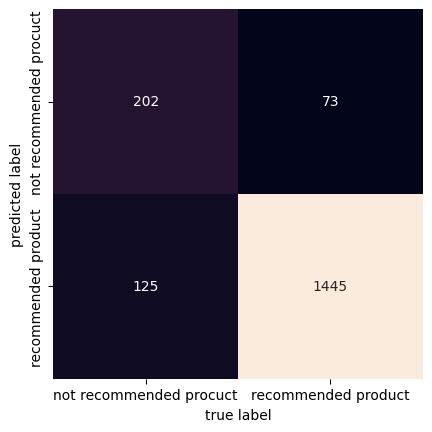

In [48]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

classes=['not recommended procuct','recommended product']
mat = confusion_matrix(y_test, y_pred_linear_SVC)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False, xticklabels=classes, yticklabels=classes)
plt.xlabel('true label')
plt.ylabel('predicted label')
plt.show()


Our suspicions are confirmed, we misclassified 73 products as not-recommended but these were actually recommended, causing recall to drop down to 95%. Also, our model recommended 125 products that should not have been recommended, causing precision to drop down to 92%.

## Fine-Tuning Pipeline

Therefore, let's now look into optimizing the model a bit further. Since GridSearch might take too much to run, let's use RandomizeSearch instead:

In [49]:
from sklearn.model_selection import RandomizedSearchCV

Before selecting the parameters to optimize, let's have a look at all possible parameters

In [50]:
SVC_pipeline.get_params().keys()

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'columntransformer', 'linearsvc', 'columntransformer__force_int_remainder_cols', 'columntransformer__n_jobs', 'columntransformer__remainder', 'columntransformer__sparse_threshold', 'columntransformer__transformer_weights', 'columntransformer__transformers', 'columntransformer__verbose', 'columntransformer__verbose_feature_names_out', 'columntransformer__num', 'columntransformer__cat', 'columntransformer__character_counts', 'columntransformer__tfidf_text', 'columntransformer__num__memory', 'columntransformer__num__steps', 'columntransformer__num__transform_input', 'columntransformer__num__verbose', 'columntransformer__num__imputer', 'columntransformer__num__scaler', 'columntransformer__num__imputer__add_indicator', 'columntransformer__num__imputer__copy', 'columntransformer__num__imputer__fill_value', 'columntransformer__num__imputer__keep_empty_features', 'columntransformer__num__imputer__missing_values', 'columntransformer__n

From Linear SVC, we have chosen C, penalty and Loss. However, we must consider not all possible combinations of these parameters will work. L2 is only allowed with Hinge if dual is True, with Squared hinge loss either if dual is True or False. L1 is only allowed with Squared hinge when dual is False.

Therefore, we will build our own custom dictionary of parameters to optimize computing time

In [51]:
parameters = [
    # l2 + hinge with dual=True
    {'linearsvc__penalty': ['l2'],
     'linearsvc__loss': ['hinge'],
     'linearsvc__dual': [True],
     'linearsvc__C': [0.01, 0.1, 1, 10, 100]},
    
    # l2 + squared_hinge with dual True or False
    {'linearsvc__penalty': ['l2'],
     'linearsvc__loss': ['squared_hinge'],
     'linearsvc__dual': [True, False],
     'linearsvc__C': [0.01, 0.1, 1, 10, 100]},
    
    # l1 + squared_hinge with dual=False
    {'linearsvc__penalty': ['l1'],
     'linearsvc__loss': ['squared_hinge'],
     'linearsvc__dual': [False],
     'linearsvc__C': [0.01, 0.1, 1, 10, 100]}
]

Also, though we achieved a good initial accuracy, let's tune based on F1 score. This is because data is inarguably imbalanced.

In [52]:
from sklearn.metrics import make_scorer
from sklearn.metrics import f1_score
scorer = make_scorer(f1_score)

In [53]:
optimizer = RandomizedSearchCV(SVC_pipeline, parameters, n_iter=10, scoring=scorer,cv=3, n_jobs=-1, verbose=3)
optim_fit = optimizer.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [54]:
optim_fit.best_params_

{'linearsvc__penalty': 'l2',
 'linearsvc__loss': 'squared_hinge',
 'linearsvc__dual': False,
 'linearsvc__C': 1}

Looks like the best parameters were: **Penalty L2** combined with **Squared Hinge** and **dual=False**, together with **C=1**
If we wanted to tune the pipeline even further, we could take these parameters as starting point for a future grid optimization and focus on fine tuning C or other pipeline parameters

Let's now calculate accuracy and F1 score for this model

In [55]:
model_best = optim_fit.best_estimator_

In [70]:
y_best=model_best.predict(X_test)
best_linear_SVC_results=pd.DataFrame({
    'Metric': ['accuracy', 'precision', 'recall','F1-score (macro)'],
    'Result': [
        accuracy_score(y_test, y_best),
        precision_score(y_test, y_best),
        recall_score(y_test, y_best),
        f1_score(y_test, y_best, average='macro')
    ]
})

print('Best Model results:')
best_linear_SVC_results

Best Model results:


,Metric,Result
0,accuracy,0.898645
1,precision,0.925784
2,recall,0.953228
3,F1-score (macro),0.816122


Let's also print the confusion matrix for this model

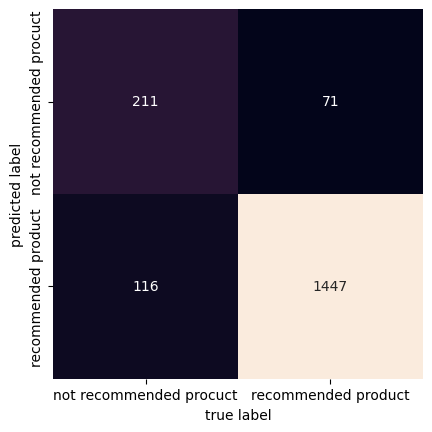

In [57]:
mat_best = confusion_matrix(y_test, y_best)
sns.heatmap(mat_best.T, square=True, annot=True, fmt='d', cbar=False, xticklabels=classes, yticklabels=classes)
plt.xlabel('true label')
plt.ylabel('predicted label')
plt.show()

In [81]:
#Add a model column to each results dataframe
inital_results=linear_SVC_results.rename(columns={'Result':'Initial result'})
best_results=best_linear_SVC_results.iloc[:, -1].rename('Best result')

results_table= pd.concat([inital_results,best_results],axis=1)
print('Model result comparison')
results_table

Model result comparison


,Metric,Initial result,Best result
0,accuracy,0.892683,0.898645
1,precision,0.920382,0.925784
2,recall,0.951910,0.953228
3,F1-score (macro),0.803489,0.816122


So, after optimization process, all metrics have improved a little bit, especially F1-score (macro). However, there would be still room for improvement, in particular if we focused more on the NLP pipeline parameters. Considering total computing time for optimization is about 15min, it isn't too bad. A finer upgrade might extend computing time exponentially.